In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

X = mnist.data / 255.0
y = mnist.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
X_train_small = X_train[:20000]
y_train_small = y_train[:20000]

In [5]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

start = time.time()

lr.fit(X_train_small, y_train_small)

lr_time = time.time() - start

In [6]:
svm = SVC(
    kernel="rbf",
    C=10,
    gamma=0.01,
    random_state=42
)

start = time.time()

svm.fit(X_train_small, y_train_small)

svm_time = time.time() - start

In [7]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

start = time.time()

rf.fit(X_train_small, y_train_small)

rf_time = time.time() - start

In [8]:
def evaluate_model(name, model):

    prediction = model.predict(X_test)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction, average="macro"),
        "Recall": recall_score(y_test, prediction, average="macro"),
        "F1 Score": f1_score(y_test, prediction, average="macro")
    }

In [9]:
results = []

results.append(evaluate_model("Logistic Regression", lr))
results.append(evaluate_model("SVM", svm))
results.append(evaluate_model("Random Forest", rf))

comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.910429,0.909251,0.909077,0.909045
1,SVM,0.974143,0.973986,0.973915,0.973934
2,Random Forest,0.955500,0.955168,0.955068,0.955078


In [10]:
time_df = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],

    "Training Time":[
        lr_time,
        svm_time,
        rf_time
    ]
})

time_df

,Model,Training Time
0,Logistic Regression,3.034722
1,SVM,21.711659
2,Random Forest,1.424933


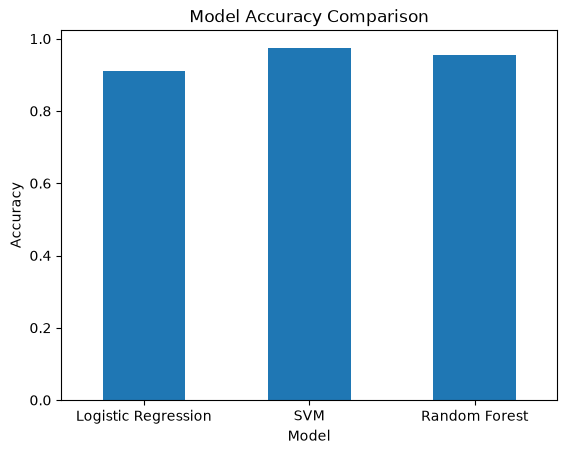

In [11]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    rot=0
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

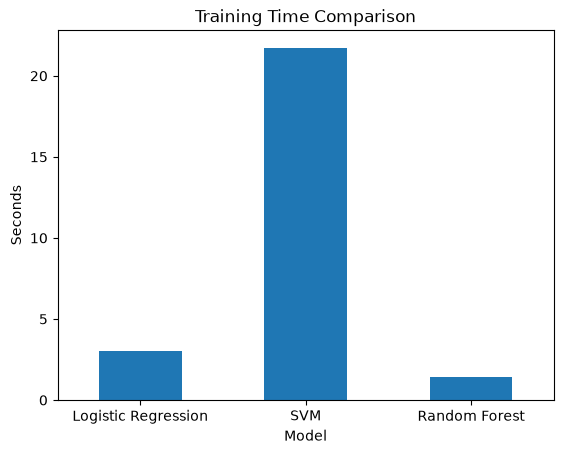

In [12]:
time_df.plot(
    x="Model",
    y="Training Time",
    kind="bar",
    legend=False,
    rot=0
)

plt.ylabel("Seconds")

plt.title("Training Time Comparison")

plt.show()


In [14]:
# Week 7 Observations

# - Logistic Regression trained the fastest but had the lowest accuracy.
# - Random Forest achieved strong accuracy with moderate training time.
# - The tuned SVM achieved the highest accuracy but required the longest training time.
# - Based on the evaluation metrics, SVM is the best-performing model for this handwritten digit classification task.